In [28]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import torch
torch.cuda.set_device(0)


print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"PyTorch CUDA version: {torch.version.cuda}")

PyTorch version: 2.5.1+cu124
CUDA available: True
PyTorch CUDA version: 12.4


In [29]:
import pandas as pd 
import os 
from neuralforecast import NeuralForecast 
from neuralforecast.models import LSTM, NHITS
from utilsforecast.plotting import plot_series
import matplotlib.pyplot as plt

In [30]:
#print("Current Working Directory:", os.getcwd())
file_path_1 = os.path.join('..', '..', 'data', 'passengers.csv')
passengers_df = pd.read_csv(file_path_1)

file_path_2 = os.path.join('..', '..', 'data', 'milk.csv')
milk_df = pd.read_csv(file_path_2)

In [31]:
passengers_df.columns = ['ds', 'y']
passengers_df['ds'] = pd.to_datetime(passengers_df['ds'])
passengers_df['unique_id'] = 1

milk_df.columns = ['ds', 'y']
milk_df['ds'] = pd.to_datetime(milk_df['ds'])
milk_df['unique_id'] = 2

In [32]:
print('passengers dtypes:', passengers_df.dtypes)
print('milk_df dtypes:', milk_df.dtypes)

passengers dtypes: ds           datetime64[ns]
y                     int64
unique_id             int64
dtype: object
milk_df dtypes: ds           datetime64[ns]
y                     int64
unique_id             int64
dtype: object


In [33]:
combined_df = pd.concat([passengers_df, milk_df], axis=0, ignore_index=True)
combined_df = combined_df[['unique_id','ds','y']].copy()

In [34]:
# Set forecast parameters
horizon = 36  
input_size = 24  

In [35]:
# Create training data by truncating each series individually
training_df = []

# Handle passengers data
passengers_cutoff = passengers_df['ds'].max() - pd.DateOffset(months=horizon)
passengers_train = passengers_df[passengers_df['ds'] <= passengers_cutoff].copy()
training_df.append(passengers_train)

# Handle milk data
milk_cutoff = milk_df['ds'].max() - pd.DateOffset(months=horizon)
milk_train = milk_df[milk_df['ds'] <= milk_cutoff].copy()
training_df.append(milk_train)

# Combine training data
training_df = pd.concat(training_df, axis=0, ignore_index=True)

In [36]:
models = [
    LSTM(
        h=horizon,
        input_size=input_size,
        max_steps=500,
        scaler_type='standard',
        encoder_hidden_size=64,
        decoder_hidden_size=64,
        batch_size=32
    ),
    NHITS(
        h=horizon,
        input_size=input_size,
        max_steps=100,
        n_freq_downsample=[2, 1, 1],
        scaler_type='standard',
        batch_size=32
    )
]

Seed set to 1
Seed set to 1


In [37]:
# Initialize and fit NeuralForecast
nf = NeuralForecast(models=models, freq='ME')
nf.fit(df=training_df, val_size=horizon)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type          | Params | Mode 
----------------------------------------------------------
0 | loss            | MAE           | 0      | train
1 | padder          | ConstantPad1d | 0      | train
2 | scaler          | TemporalNorm  | 0      | train
3 | hist_encoder    | LSTM          | 50.4 K | train
4 | context_adapter | Linear        | 23.4 K | train
5 | mlp_decoder     | MLP           | 769    | train
----------------------------------------------------------
74.6 K    Trainable params
0         Non-trainable params
74.6 K    Total params
0.298     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_steps=500` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
0         Non-trainable params
2.5 M     Total params
9.892     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.


In [38]:
# Generate predictions
Y_hat_df = nf.predict()


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

c:\Users\retailexp\Documents\GitHub\tsfwpt\.venv\Lib\site-packages\neuralforecast\core.py:209: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


In [39]:
Y_hat_df.tail(n=3)

,ds,LSTM,NHITS
unique_id,,,
2,1975-09-30,857.069702,861.416748
2,1975-10-31,850.340698,833.966736
2,1975-11-30,808.546814,862.927490


In [40]:
Y_hat_df.dtypes

ds       datetime64[ns]
LSTM            float32
NHITS           float32
dtype: object

In [41]:
# reset index for y_hat_df
Y_hat_df = Y_hat_df.reset_index().copy()

# Separate data
passengers_actual = combined_df[combined_df['unique_id'] == 1].copy()
milk_actual = combined_df[combined_df['unique_id'] == 2].copy()

# Seperate forecasts
passengers_forecast = Y_hat_df[Y_hat_df['unique_id'] == 1].copy()
milk_forecast = Y_hat_df[Y_hat_df['unique_id'] == 2].copy()

In [42]:
Y_hat_df.head(n=3)

,unique_id,ds,LSTM,NHITS
0,1,1957-12-31,283.841675,332.373138
1,1,1958-01-31,279.810822,345.447449
2,1,1958-02-28,287.883301,394.983734


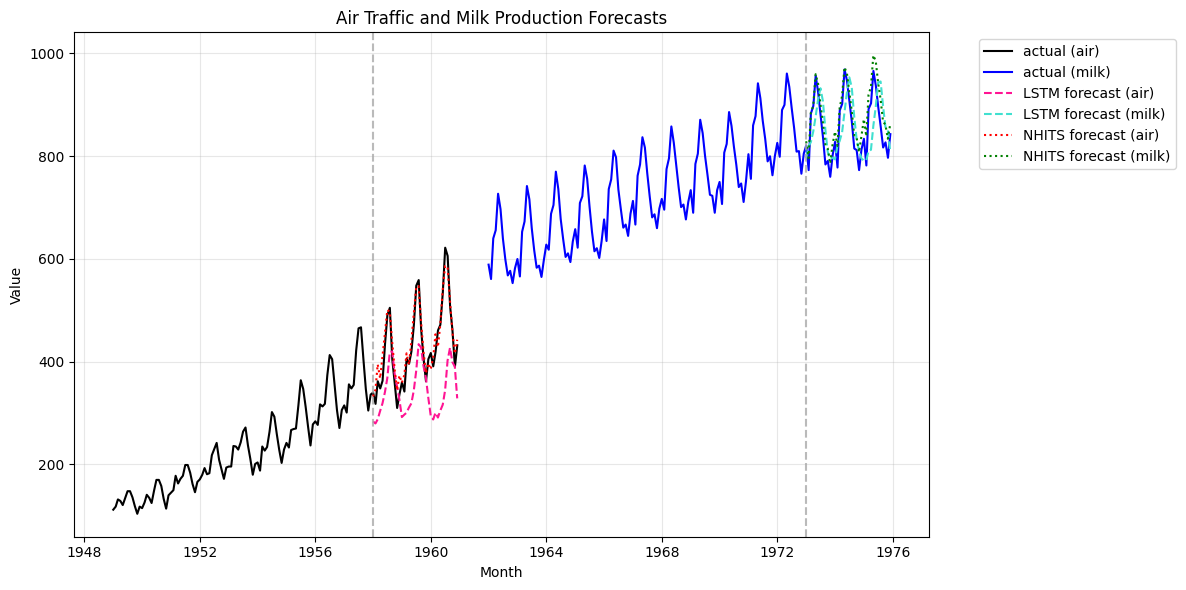

In [46]:
plt.figure(figsize=(12, 6))

# Plot actual values
plt.plot(passengers_actual['ds'], passengers_actual['y'], 
         color='black', label='actual (air)')
plt.plot(milk_actual['ds'], milk_actual['y'], 
         color='blue', label='actual (milk)')

# Plot forecasts for both models
# LSTM forecasts
plt.plot(passengers_forecast['ds'], passengers_forecast['LSTM'], 
         color='deeppink', linestyle='--', label='LSTM forecast (air)')
plt.plot(milk_forecast['ds'], milk_forecast['LSTM'], 
         color='turquoise', linestyle='--', label='LSTM forecast (milk)')

# NHITS forecasts
plt.plot(passengers_forecast['ds'], passengers_forecast['NHITS'], 
         color='red', linestyle=':', label='NHITS forecast (air)')
plt.plot(milk_forecast['ds'], milk_forecast['NHITS'], 
         color='green', linestyle=':', label='NHITS forecast (milk)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Air Traffic and Milk Production Forecasts')
plt.xlabel('Month')
plt.ylabel('Value')
plt.grid(True, alpha=0.3)

# Add vertical line at the forecast start
forecast_start_air = Y_hat_df[Y_hat_df['unique_id'] == 1]['ds'].min()
forecast_start_milk = Y_hat_df[Y_hat_df['unique_id'] == 2]['ds'].min()
plt.axvline(x=forecast_start_air, color='darkgray', linestyle='--', alpha=0.8)
plt.axvline(x=forecast_start_milk, color='darkgray', linestyle='--', alpha=0.8)

plt.tight_layout()
plt.show()


In [51]:
from functools import partial
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mse, rmse, mase, mape, smape

In [57]:
model_names = ['LSTM', 'NHITS']
metrics = [
    mae,
    mse,
    rmse,
    mape,
    smape,
    partial(mase, seasonality=12)
]

In [102]:
Y_hat_df['ds'] = pd.to_datetime(Y_hat_df['ds'])
combined_df['ds'] = pd.to_datetime(combined_df['ds'])

In [105]:
Y_hat_df['ds'] = Y_hat_df['ds'] + pd.DateOffset(days=1)

In [106]:
eval_df = Y_hat_df.merge(
    combined_df[['unique_id', 'ds', 'y']], 
    on=['unique_id', 'ds'], 
    how='left'
)

In [107]:
eval_df

,unique_id,ds,LSTM,NHITS,y
0,1,1958-01-01,283.841675,332.373138,340
1,1,1958-02-01,279.810822,345.447449,318
2,1,1958-03-01,287.883301,394.983734,362
3,1,1958-04-01,304.175659,367.709930,348
4,1,1958-05-01,319.165710,411.242859,363
...,...,...,...,...,...
67,2,1975-08-01,945.522217,911.042725,858
68,2,1975-09-01,897.934570,867.291382,817
69,2,1975-10-01,857.069702,861.416748,827
70,2,1975-11-01,850.340698,833.966736,797


In [108]:

fcst_mase = partial(mase, seasonality=12)
# Get metrics for individual series
series_metrics = evaluate(
    eval_df, 
    models=['NHITS', 'LSTM'], # Specify model names (in cols of eval_df)
    metrics=[mae, mse, rmse, fcst_mase, mape, smape],  
    train_df=training_df,      
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

In [109]:
series_metrics

,unique_id,metric,NHITS,LSTM
0,1,mae,19.044879,89.640498
1,2,mae,25.950794,49.276978
2,1,mse,515.575219,12029.756908
3,2,mse,886.260697,3050.580024
4,1,rmse,22.706281,109.680248
5,2,rmse,29.770131,55.232056
6,1,mase,0.622933,2.932023
7,2,mase,1.083918,2.058210
8,1,mape,0.047616,0.196225
9,2,mape,0.030975,0.057081
